# QickworkspaceV2 native HDF5 reader demo
This notebook indexes a Data path, searches repeated measurements across dates, selectively reads raw data, and plots by stable `plot_id`. No QICK hardware is required.

> Select a Python environment containing `h5py`, `numpy`, `matplotlib`, and `ipykernel`.

In [10]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in (cwd, *cwd.parents) if (p / 'QickworkspaceV2').is_dir()), cwd)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from QickworkspaceV2.tools import ExperimentArchive

DATA_ROOT = REPO_ROOT / 'tutorial' / 'read_tool' / 'data'
archive = ExperimentArchive(DATA_ROOT)
DATA_ROOT, archive.stats()

(PosixPath('/Users/jay/Desktop/QickworkspaceV2 project/tutorial/read_tool/data'),
 {'total': 76,
  'experiment_types': {'ssh_readout_optimize': 4,
   's016_state_tomography_ge': 5,
   's015_RB_ge': 8,
   's010_single_shot_ge': 15,
   's004_power_rabi_ge': 22,
   's008_T1_ge': 22},
  'qubits': {'Q1': 55, 'Q2': 21},
  'qualities': {'good': 73, 'warning': 3}})

## Lightweight index — no raw arrays are loaded

In [11]:
records = archive.all()
[(r.timestamp_local, r.experiment_type, r.qubits, r.tags, r.comment_preview) for r in records[:12]]

[('2026-07-14T18:20:00+08:00',
  'ssh_readout_optimize',
  ('Q1',),
  ('demo', 'repeated', 'SSH', 'optimization', 'day-20260714', 'Q1'),
  'Q1 SSH optimization，日期 2026-07-14'),
 ('2026-07-14T18:15:00+08:00',
  's016_state_tomography_ge',
  ('Q1',),
  ('demo', 'repeated', 'tomography', 'day-20260714', 'Q1'),
  'Q1 隔日 tomography，日期 2026-07-14'),
 ('2026-07-14T18:10:00+08:00',
  's015_RB_ge',
  ('Q1',),
  ('demo', 'repeated', 'RB', 'day-20260714', 'Q1'),
  'Q1 daily RB，日期 2026-07-14'),
 ('2026-07-14T18:04:00+08:00',
  's010_single_shot_ge',
  ('Q2',),
  ('demo', 'repeated', 'single-shot', 'day-20260714', 'Q2'),
  'Q2 每日 single-shot check，日期 2026-07-14'),
 ('2026-07-14T18:00:00+08:00',
  's010_single_shot_ge',
  ('Q1',),
  ('demo', 'repeated', 'single-shot', 'day-20260714', 'Q1'),
  'Q1 每日 single-shot check，日期 2026-07-14'),
 ('2026-07-14T17:49:00+08:00',
  's004_power_rabi_ge',
  ('Q2',),
  ('demo', 'repeated', 'day-20260714', 'Q2', 'rabi'),
  'Q2 Rabi 重複量測 #3，日期 2026-07-14'),
 ('2026-07-1

## Repeated measurements across dates

In [ ]:
history = archive.query(
    experiment_type='s008_T1_ge', qubit='Q1', tags=['repeated'],
    start='2026-07-08', end='2026-07-14',
)
[(r.timestamp_local, r.session_id, r.quality, r.comment_preview) for r in history]

[('2026-07-13T17:38:00+08:00',
  'cooldown-20260713',
  'good',
  'Q1 T1 重複量測 #2，日期 2026-07-13'),
 ('2026-07-13T17:30:00+08:00',
  'cooldown-20260713',
  'good',
  'Q1 T1 重複量測 #1，日期 2026-07-13'),
 ('2026-07-12T17:38:00+08:00',
  'cooldown-20260712',
  'good',
  'Q1 T1 重複量測 #2，日期 2026-07-12'),
 ('2026-07-12T17:30:00+08:00',
  'cooldown-20260712',
  'warning',
  'Q1 T1 重複量測 #1，日期 2026-07-12'),
 ('2026-07-11T17:38:00+08:00',
  'cooldown-20260711',
  'good',
  'Q1 T1 重複量測 #2，日期 2026-07-11'),
 ('2026-07-11T17:30:00+08:00',
  'cooldown-20260711',
  'good',
  'Q1 T1 重複量測 #1，日期 2026-07-11'),
 ('2026-07-10T17:38:00+08:00',
  'cooldown-20260710',
  'good',
  'Q1 T1 重複量測 #2，日期 2026-07-10'),
 ('2026-07-10T17:30:00+08:00',
  'cooldown-20260710',
  'good',
  'Q1 T1 重複量測 #1，日期 2026-07-10'),
 ('2026-07-09T17:38:00+08:00',
  'cooldown-20260709',
  'warning',
  'Q1 T1 重複量測 #2，日期 2026-07-09'),
 ('2026-07-09T17:30:00+08:00',
  'cooldown-20260709',
  'good',
  'Q1 T1 重複量測 #1，日期 2026-07-09'),
 ('2026-07-08T

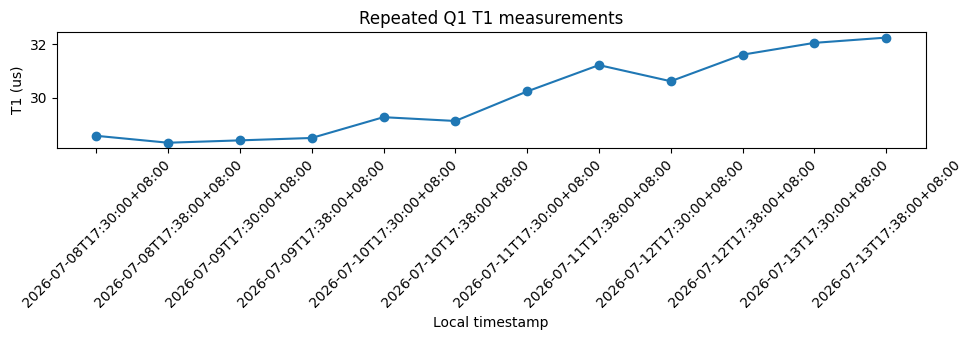

In [16]:
trend = [(r.timestamp_local, r.load().fit_result['T1_us'][0]) for r in reversed(history)]
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot([item[0] for item in trend], [item[1] for item in trend], 'o-')
ax.tick_params(axis='x', rotation=45)
ax.set(title='Repeated Q1 T1 measurements', ylabel='T1 (us)', xlabel='Local timestamp')
fig.tight_layout()

In [17]:
t1 = history[0]
t1.inspect()  # full comment/config/metadata, still without raw IQ

{'path': '/Users/jay/Desktop/QickworkspaceV2 project/tutorial/read_tool/data/2026/07/2026-07-13/173800_000000_s008_T1_ge_Q1_W8DD3E7M.h5',
 'analysis_id': 't1',
 'data_kind': 'sweep_1d',
 'experiment_id': '20260714T145529179523Z-75NNSW8DD3E7M',
 'experiment_type': 's008_T1_ge',
 'interrupted': False,
 'plot_id': 'iq_fit_1d',
 'quality': 'good',
 'schema_name': 'qickworkspace.experiment',
 'schema_version': '1.0',
 'timestamp_local': '2026-07-13T17:38:00+08:00',
 'timestamp_utc': '2026-07-13T09:38:00+00:00',
 'write_complete': True,
 'comment': 'Q1 T1 重複量測 #2，日期 2026-07-13',
 'tags': ['demo', 'repeated', 'day-20260713', 'Q1', 'T1'],
 'metadata': {'qubit': 'Q1', 'repeat': 1, 'day_index': 5},
 'config': {'name': 'Q1'},
 'lineage': {'session_id': 'cooldown-20260713',
  'parent_id': None,
  'children': []},
 'qubits': ['Q1']}

## Inspect and selectively load datasets

In [18]:
t1.raw_keys(), t1.analysis_keys(), t1.axes()

(['iq'],
 ['fit_curve', 'residual'],
 {'delay_us': {'values': array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
           11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
           22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
           33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
           44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
           55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
           66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
           77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
           88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
           99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
          110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.]),
   'label': 'Delay',
   'unit': 'us'}})

In [19]:
iq = t1.load_raw('iq', selection={'delay_us': slice(0, 10)})
iq.dataset, iq.dims, iq.shape, iq.values[:3], iq.axes

('raw/iq',
 ('delay_us',),
 (10,),
 array([1.036854  +0.04956244j, 1.01632821+0.06192225j,
        0.96392849+0.04203796j]),
 {'delay_us': array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])})

In [23]:
single_shot = archive.latest('s010_single_shot_ge', qubit='Q2')
e_shots = single_shot.load_raw('iq', selection={'state': 'e', 'shot': slice(0, 20)})
e_shots.dims, e_shots.shape, e_shots.values[:3]

(('shot',),
 (20,),
 array([0.99281104+0.0986024j , 1.0846818 +0.38769986j,
        0.72070177-0.00595589j]))

## Plot a representative subset from stored plot IDs

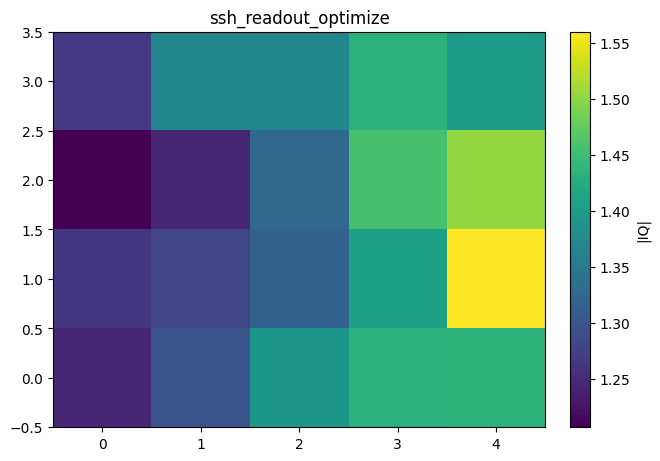

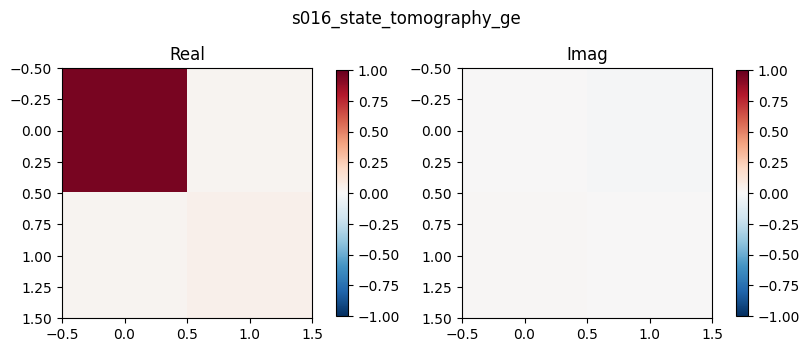

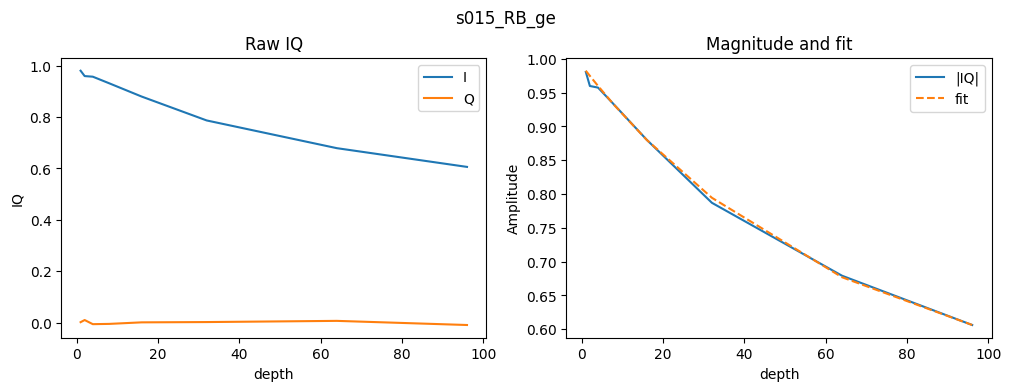

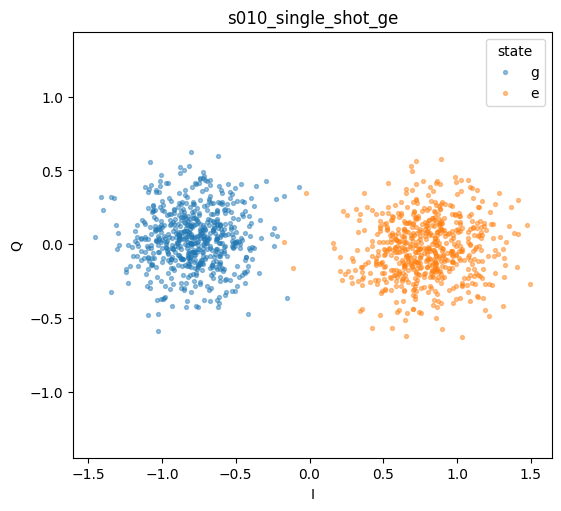

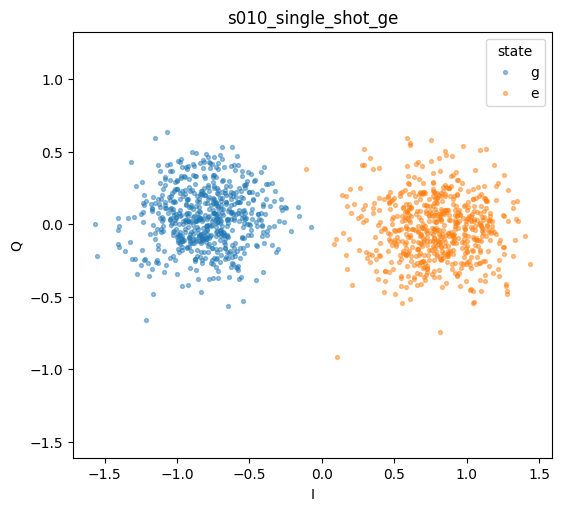

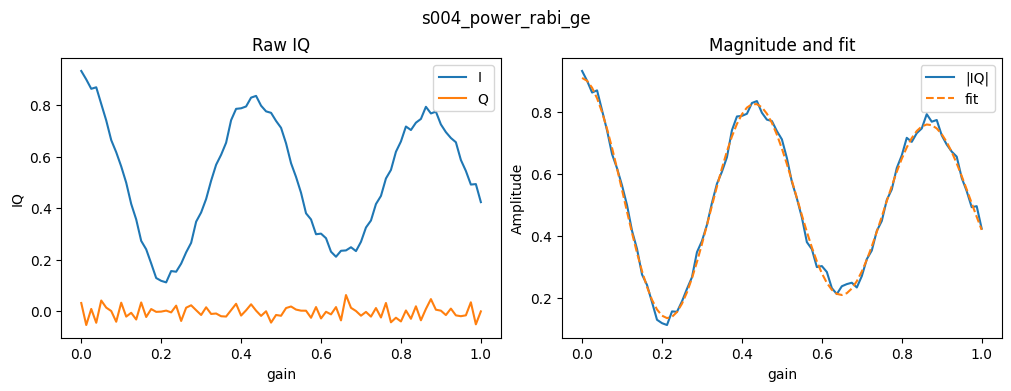

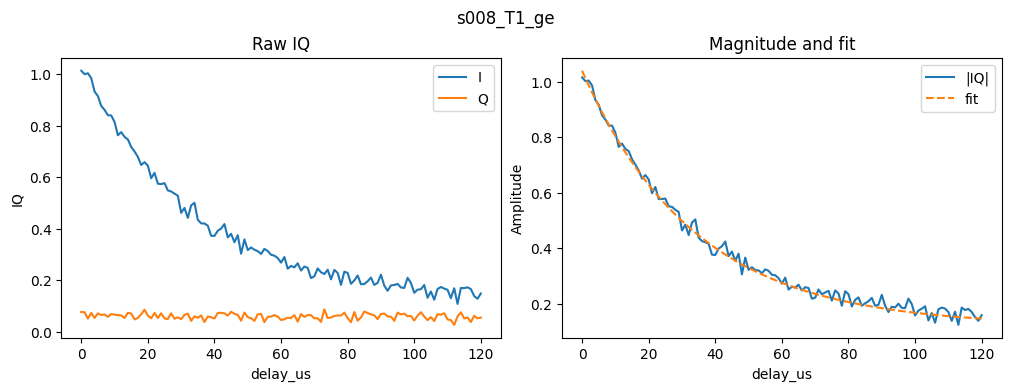

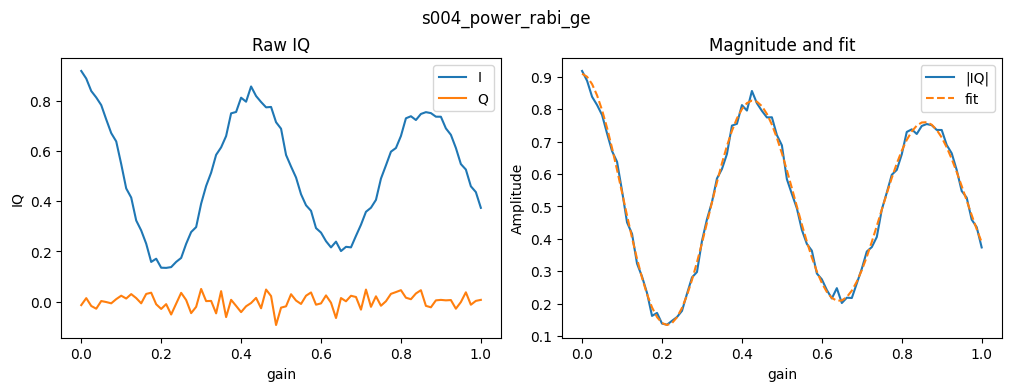

In [24]:
for record in archive.all(limit=8):
    fig = record.plot()
    plt.show()
    plt.close(fig)

## Full load only when needed

In [25]:
result = t1.load()
result.experiment_id, result.comment, result.fit_result, result.raw_iq.shape

('20260714T145529179523Z-75NNSW8DD3E7M',
 'Q1 T1 重複量測 #2，日期 2026-07-13',
 {'T1_us': [32.241072311462304, 0.75]},
 (121,))